# FormTrapAI
## A Semi-Supervised Lightweight Inference Framework for Behavioral Pattern Detection of Application Layer Data Submission Abuse

---

### Problem
Traditional rule-based form protection (honeypots, timing checks) is increasingly bypassed by modern bots that mimic human behavior. Existing AI solutions require large datasets, cloud services, or deep learning — impractical for edge servers and low-resource environments.

### Approach
FormTrapAI combines three components:
1. **Rule Engine** — generates weak labels from behavioral heuristics (no manual annotation needed)
2. **Semi-Supervised XGBoost** — leverages both labeled and unlabeled submissions to improve accuracy without overfitting
3. **K-Means Clustering** — discovers behavioral groups and identifies previously unseen attack patterns

### Key Design Constraints
- Behavioral signals only (no message content / TF-IDF)
- Edge server deployment (CPU-only, no GPU)
- Imbalance-aware evaluation (dataset is majority-bot)

### Baselines Compared
| Baseline | Description |
|---|---|
| B1 | Rule-based system only |
| B2 | Supervised XGBoost (labeled data only) |
| B3 | FormTrapAI — rule labels + semi-supervised XGBoost |

---
## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math
import time
import tracemalloc
from collections import Counter

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')
print('Setup complete.')

Setup complete.


---
## 2. Data Loading & Exploration

In [2]:
# Load the SpamCleaned sheet — cleaned form submission dataset (5766 rows)
df = pd.read_excel('../Data/data.xlsx', sheet_name='SpamCleaned')
print(f'Dataset shape: {df.shape}')
print('Columns:', df.columns.tolist())
df.head()

Dataset shape: (5766, 8)
Columns: ['First name', 'Middle name', 'Last name', 'Full name', 'Email', 'Phone Number', 'Subject', 'Message']


,First name,Middle name,Last name,Full name,Email,Phone Number,Subject,Message
0,EdwardNex,EdwardNexFR,EdwardNexFR,NaN,avitopost24@rambler.ru,89347784874,NaN,Здравствуйте! \n \nПредлагаем массовое размеще...
1,JimmySiG,JimmySiGAI,JimmySiGAI,NaN,sdfwedfnerg@rambler.ru,87985992322,NaN,Представляем удаленный отдел продаж http://top...
2,Mike,Mike AX,Mike AX,NaN,no-replysob@google.com,81498215433,NaN,Hеllо! \nIf you want to get ahead of your comp...
3,DennisHob,DennisHobJQ,DennisHobJQ,NaN,fwetsx5@rambler.ru,87677486522,NaN,Здравствуйте! \n \nВашей компании нужна свежая...
4,RobertDon,RobertDonGK,RobertDonGK,NaN,atrixxtrix@gmail.com,83718338333,NaN,"Dear Sir/mdm, \n \nHow are you? \n \nWe supply..."


In [3]:
print('Null counts per column:')
print(df.isnull().sum())
print(f'\nTotal rows: {len(df):,}')

Null counts per column:
First name      4907
Middle name     4908
Last name       4907
Full name       1364
Email           2712
Phone Number    2720
Subject         5711
Message          527
dtype: int64

Total rows: 5,766


In [4]:
# Ground-truth label proxy using URL count in message
# The original URL-honeypot column is no longer present in the dataset.
# Proxy strategy (behaviorally grounded):
#   - >= 2 URLs in message → Bot (1)   [spam always embeds multiple links]
#   - 0 URLs in message   → Human (0)  [legitimate submissions rarely have links]
#   - 1 URL in message    → Uncertain (-1) [ambiguous — left for semi-supervised]
df['_num_links_raw'] = df['Message'].fillna('').str.count('http')

df['isBot'] = -1
df.loc[df['_num_links_raw'] >= 2, 'isBot'] = 1
df.loc[df['_num_links_raw'] == 0, 'isBot'] = 0

counts = df['isBot'].value_counts()
print('Label distribution:')
print(f'  Human     (0):  {counts.get(0, 0):,}')
print(f'  Bot       (1):  {counts.get(1, 0):,}')
print(f'  Uncertain (-1): {counts.get(-1, 0):,}')
print(f'\nBot ratio among high-confidence rows: '
      f'{counts.get(1,0) / (counts.get(0,0)+counts.get(1,0))*100:.1f}%')

Label distribution:
  Human     (0):  1,745
  Bot       (1):  1,292
  Uncertain (-1): 2,729

Bot ratio among high-confidence rows: 42.5%


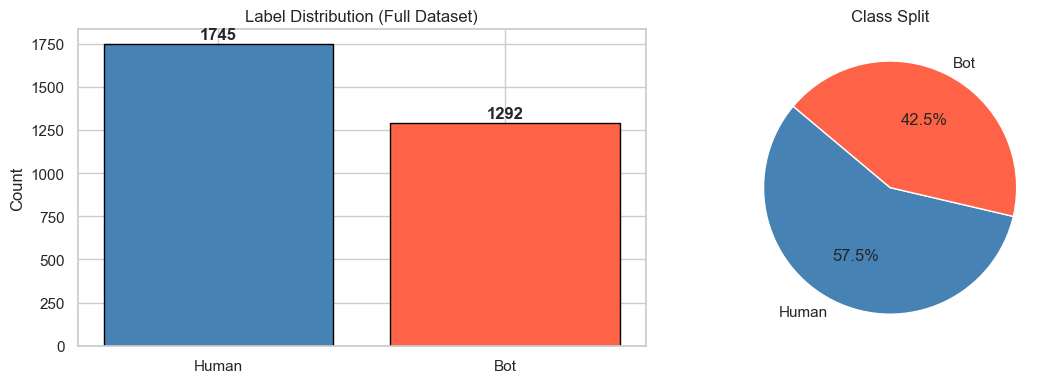

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Label distribution bar
axes[0].bar(['Human', 'Bot'], [counts.get(0,0), counts.get(1,0)],
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Label Distribution (Full Dataset)')
axes[0].set_ylabel('Count')
for i, v in enumerate([counts.get(0,0), counts.get(1,0)]):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie([counts.get(0,0), counts.get(1,0)],
            labels=['Human', 'Bot'],
            colors=['steelblue', 'tomato'],
            autopct='%1.1f%%', startangle=140)
axes[1].set_title('Class Split')

plt.tight_layout()
plt.show()

---
## 3. Behavioral Feature Engineering

FormTrapAI uses **behavioral signals only** — no message content, no TF-IDF, no timestamps.  
This makes the system robust to language changes, obfuscation, and novel message patterns.

| Feature | Description |
|---|---|
| `field_completion_ratio` | Fraction of non-empty fields |
| `input_entropy` | Shannon entropy of message text |
| `input_length` | Total chars across all text fields |
| `numeric_character_ratio` | Digits / total chars in message |
| `repeated_submission_flag` | Same email submitted before (0/1) |
| `num_links` | HTTP URL count in message |
| `num_special_chars` | Special character count in message |
| `email_is_free_domain` | Gmail/Yahoo/Hotmail/Rambler (0/1) |

In [6]:
def shannon_entropy(text):
    """Compute Shannon entropy of a string."""
    text = str(text)
    if len(text) == 0:
        return 0.0
    freq = Counter(text)
    total = len(text)
    return -sum((c/total) * math.log2(c/total) for c in freq.values())

def extract_behavioral_features(df):
    feat = pd.DataFrame(index=df.index)

    # --- Text fields ---
    msg   = df['Message'].fillna('').astype(str)      if 'Message'      in df.columns else pd.Series('', index=df.index)
    email = df['Email'].fillna('').astype(str)         if 'Email'        in df.columns else pd.Series('', index=df.index)
    phone = df['Phone Number'].fillna('').astype(str)  if 'Phone Number' in df.columns else pd.Series('', index=df.index)
    fname = df['First name'].fillna('').astype(str)    if 'First name'   in df.columns else pd.Series('', index=df.index)
    lname = df['Last name'].fillna('').astype(str)     if 'Last name'    in df.columns else pd.Series('', index=df.index)
    subj  = df['Subject'].fillna('').astype(str)       if 'Subject'      in df.columns else pd.Series('', index=df.index)
    mname = df['Middle name'].fillna('').astype(str)   if 'Middle name'  in df.columns else pd.Series('', index=df.index)

    all_text = msg + email + phone + fname + lname + subj

    # --- Field completion ratio ---
    text_cols = [c for c in ['First name', 'Last name', 'Email', 'Phone Number',
                              'Subject', 'Message', 'Middle name'] if c in df.columns]
    filled = df[text_cols].notna() & (df[text_cols].astype(str).apply(
        lambda col: col.str.strip()) != '')
    feat['field_completion_ratio'] = filled.sum(axis=1) / max(len(text_cols), 1)

    # --- Input entropy (Shannon entropy of message) ---
    feat['input_entropy'] = msg.apply(shannon_entropy)

    # --- Input length (all text combined) ---
    feat['input_length'] = all_text.str.len()

    # --- Numeric character ratio (digits in message) ---
    def numeric_ratio(text):
        text = str(text)
        return sum(c.isdigit() for c in text) / len(text) if text else 0.0
    feat['numeric_character_ratio'] = msg.apply(numeric_ratio)

    # --- Repeated submission flag (duplicate email seen earlier) ---
    seen = set()
    repeated = []
    for e in email:
        e_lower = e.strip().lower()
        if e_lower and e_lower in seen:
            repeated.append(1)
        else:
            repeated.append(0)
            if e_lower:
                seen.add(e_lower)
    feat['repeated_submission_flag'] = repeated

    # --- Number of HTTP links in message ---
    feat['num_links'] = msg.str.lower().str.count('http')

    # --- Special characters in message ---
    feat['num_special_chars'] = msg.str.count(r'[!@#$%^&*()]')

    # --- Free/suspicious email domain ---
    free_domains = ['gmail', 'yahoo', 'hotmail', 'outlook', 'mail.ru', 'yandex', 'rambler']
    feat['email_is_free_domain'] = email.apply(
        lambda e: int(any(d in e.lower() for d in free_domains))
    )

    return feat

features_df = extract_behavioral_features(df)
print(f'Feature matrix shape: {features_df.shape}')
print('Features:', features_df.columns.tolist())
features_df.head()

Feature matrix shape: (5766, 8)
Features: ['field_completion_ratio', 'input_entropy', 'input_length', 'numeric_character_ratio', 'repeated_submission_flag', 'num_links', 'num_special_chars', 'email_is_free_domain']


,field_completion_ratio,input_entropy,input_length,numeric_character_ratio,repeated_submission_flag,num_links,num_special_chars,email_is_free_domain
0,0.857143,4.917817,1096,0.007670,0,2,9,1
1,0.857143,4.964315,656,0.000000,0,3,1,1
2,0.857143,4.685357,443,0.015075,0,1,2,0
3,0.857143,5.070500,1023,0.000000,0,3,11,1
4,0.857143,5.006070,1008,0.040752,0,1,3,1


In [7]:
# Feature statistics
features_df.describe().round(3)

,field_completion_ratio,input_entropy,input_length,numeric_character_ratio,repeated_submission_flag,num_links,num_special_chars,email_is_free_domain
count,5766.000,5766.000,5766.000,5766.000,5766.000,5766.000,5766.000,5766.000
mean,0.346,4.143,567.643,0.019,0.205,2.947,6.092,0.379
std,0.251,1.415,1716.529,0.041,0.403,29.509,81.865,0.485
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.143,4.163,69.000,0.000,0.000,0.000,0.000,0.000
50%,0.286,4.492,140.000,0.001,0.000,1.000,0.000,0.000
75%,0.429,4.810,495.000,0.023,0.000,1.000,1.000,1.000
max,0.857,7.772,36469.000,0.667,1.000,799.000,2354.000,1.000


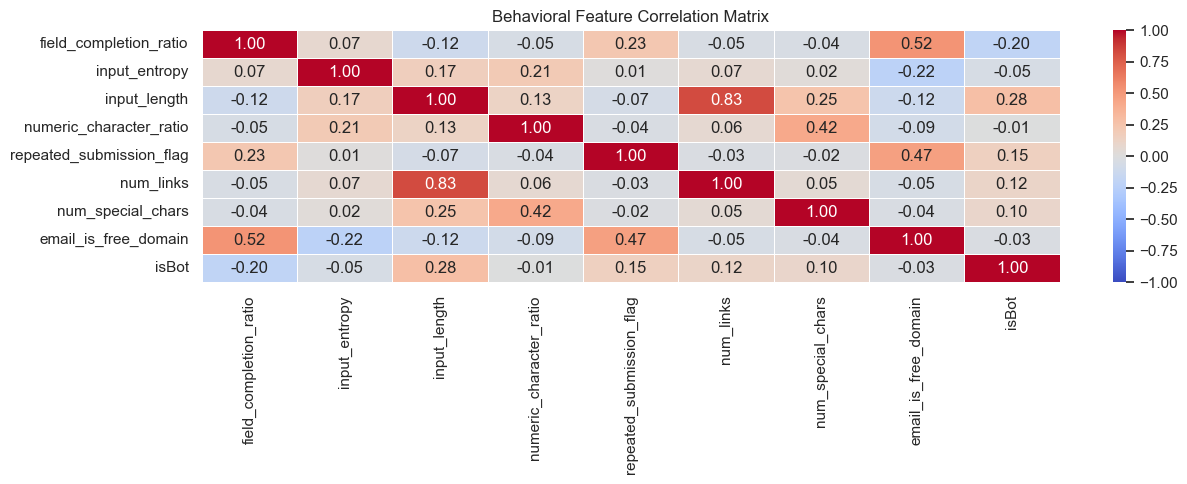

In [8]:
# Correlation heatmap of behavioral features vs label
corr_df = features_df.copy()
corr_df['isBot'] = df['isBot']

plt.figure(figsize=(13, 5))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Behavioral Feature Correlation Matrix')
plt.tight_layout()
plt.show()

---
## 4. Rule Engine — Weak Label Generation

The Rule Engine converts behavioral signals into weak labels without requiring manual annotation.  
These weak labels serve as the training signal for the semi-supervised classifier.

| Rule | Label | Confidence |
|---|---|---|
| num_links ≥ 2 | 1 (Bot) | High — spam always embeds multiple links |
| input_entropy < 1.5 AND input_length > 10 | 1 (Bot) | Medium — very low-entropy text is templated/automated |
| num_links == 1 AND email_is_free_domain == 1 | 1 (Bot) | Medium — single-link spam from free domains |
| field_completion_ratio < 0.2 | -1 (Unlabeled/Suspicious) | — |
| repeated_submission_flag == 1 | -1 (Unlabeled/Suspicious) | — |
| All rules pass (normal behavior) | 0 (Human) | Medium |

In [9]:
def rule_engine(feat):
    """
    Returns weak labels: 1 (Bot), 0 (Human), -1 (Unlabeled/Suspicious)
    Priority: definitive bot signals first, then suspicious, then human.
    """
    labels = np.full(len(feat), -1, dtype=int)

    num_links = feat['num_links'].values
    entropy   = feat['input_entropy'].values
    inp_len   = feat['input_length'].values
    fcr       = feat['field_completion_ratio'].values
    repeated  = feat['repeated_submission_flag'].values
    free_dom  = feat['email_is_free_domain'].values

    # Bot signals
    is_bot = (
        (num_links >= 2) |                              # multiple spam links
        ((entropy < 1.5) & (inp_len > 10)) |            # low-entropy templated text
        ((num_links == 1) & (free_dom == 1))            # single link from free domain
    )

    # Suspicious (ambiguous — leave for semi-supervised)
    is_suspicious = (~is_bot) & ((fcr < 0.2) | (repeated == 1))

    # Likely human
    is_human = (~is_bot) & (~is_suspicious)

    labels[is_bot]        = 1
    labels[is_human]      = 0
    labels[is_suspicious] = -1

    return labels

weak_labels = rule_engine(features_df)

wl_counts = Counter(weak_labels)
print('Weak label distribution:')
print(f'  Bot       (1):  {wl_counts[1]:,}  ({wl_counts[1]/len(weak_labels)*100:.1f}%)')
print(f'  Human     (0):  {wl_counts[0]:,}  ({wl_counts[0]/len(weak_labels)*100:.1f}%)')
print(f'  Unlabeled (-1): {wl_counts[-1]:,}  ({wl_counts[-1]/len(weak_labels)*100:.1f}%)')

Weak label distribution:
  Bot       (1):  2,624  (45.5%)
  Human     (0):  629  (10.9%)
  Unlabeled (-1): 2,513  (43.6%)


In [10]:
# Rule engine agreement vs proxy ground truth (high-confidence rows only: isBot != -1)
gt_mask   = df['isBot'].values != -1
rule_pred = weak_labels[gt_mask]
gt_labels = df['isBot'].values[gt_mask]

print(f'High-confidence ground truth rows: {gt_mask.sum():,}')
print(f'  Human (0): {(gt_labels==0).sum():,}  |  Bot (1): {(gt_labels==1).sum():,}')
print()
print('Rule Engine (B1) — evaluated on high-confidence rows:')
print(classification_report(gt_labels, np.where(rule_pred==-1, 0, rule_pred),
                            target_names=['Human', 'Bot']))
ba  = balanced_accuracy_score(gt_labels, np.where(rule_pred==-1, 0, rule_pred))
mf1 = f1_score(gt_labels, np.where(rule_pred==-1, 0, rule_pred), average='macro')
print(f'Balanced Accuracy: {ba:.4f}')
print(f'Macro F1:          {mf1:.4f}')

High-confidence ground truth rows: 3,037
  Human (0): 1,745  |  Bot (1): 1,292

Rule Engine (B1) — evaluated on high-confidence rows:
              precision    recall  f1-score   support

       Human       1.00      0.77      0.87      1745
         Bot       0.77      1.00      0.87      1292

    accuracy                           0.87      3037
   macro avg       0.88      0.89      0.87      3037
weighted avg       0.90      0.87      0.87      3037

Balanced Accuracy: 0.8871
Macro F1:          0.8702


---
## 5. Semi-Supervised XGBoost Training

XGBoost is wrapped with `SelfTrainingClassifier` to exploit unlabeled data via pseudo-labeling.  
Class imbalance is corrected with `scale_pos_weight` — this prevents the model from over-predicting the majority (bot) class.

In [11]:
X      = features_df.values          # all 5766 rows, 8 features
y_gt   = df['isBot'].values          # proxy ground truth: 0/1/-1
y_weak = weak_labels.copy()          # rule-engine weak labels: 0/1/-1

# Class weight for XGBoost — computed from rule-labeled rows only
n_human = (y_weak == 0).sum()
n_bot   = (y_weak == 1).sum()
scale_pos_weight = n_human / n_bot if n_bot > 0 else 1.0
print(f'Rule-labeled:  Human={n_human:,}  Bot={n_bot:,}')
print(f'scale_pos_weight: {scale_pos_weight:.3f}')

# XGBoost base estimator
base_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# Semi-supervised wrapper (sklearn >=1.2 uses 'estimator' not 'base_estimator')
ssl_model = SelfTrainingClassifier(
    estimator=base_xgb,
    threshold=0.80,
    criterion='threshold',
    verbose=True
)

Rule-labeled:  Human=629  Bot=2,624
scale_pos_weight: 0.240


---
## 6. Imbalance-Aware Evaluation

### 6a. Stratified 80/20 Train-Test Split
We split the **full dataset** into 80% train / 20% test using stratified sampling to preserve the class ratio.  
The test set uses ground-truth labels. The training set uses **weak labels** (including -1 for unlabeled rows).

In [12]:
# Stratified 80/20 split on HIGH-CONFIDENCE rows (proxy ground truth 0/1 only)
hc_mask = y_gt != -1
X_hc    = X[hc_mask]
y_hc_gt = y_gt[hc_mask]

X_train_hc, X_test, y_train_hc, y_test_gt = train_test_split(
    X_hc, y_hc_gt,
    test_size=0.20,
    stratify=y_hc_gt,
    random_state=42
)

# Full training set: high-confidence train + remaining uncertain rows (unlabeled)
# Build combined X_train and y_train_weak for semi-supervised fit
hc_train_idx = np.where(hc_mask)[0]
# We'll fit ssl_model on all rows, using y_weak for training signal
X_train_all  = X                    # all 5766 rows
y_train_weak = y_weak.copy()        # 0/1/-1 from rule engine

print(f'High-confidence rows: {hc_mask.sum():,}  (Human: {(y_hc_gt==0).sum()}, Bot: {(y_hc_gt==1).sum()})')
print(f'Test set (20% of HC): {len(X_test):,}  (Human: {(y_test_gt==0).sum()}, Bot: {(y_test_gt==1).sum()})')

High-confidence rows: 3,037  (Human: 1745, Bot: 1292)
Test set (20% of HC): 608  (Human: 349, Bot: 259)


In [13]:
# Train FormTrapAI (B3) on ALL rows using weak labels
tracemalloc.start()
t0 = time.perf_counter()

ssl_model.fit(X_train_all, y_train_weak)

train_time = time.perf_counter() - t0
_, mem_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f'Training time:  {train_time:.2f}s')
print(f'Peak memory:    {mem_peak / 1024**2:.1f} MB')

End of iteration 1, added 986 new labels.


End of iteration 2, added 1527 new labels.


Training time:  2.77s
Peak memory:    0.6 MB


In [14]:
# Pseudo-label stats
n_labeled    = (ssl_model.labeled_iter_ != -1).sum()
n_unlabeled  = (ssl_model.labeled_iter_ == -1).sum()
print(f'Pseudo-labeled: {n_labeled:,} samples')
print(f'Remained unlabeled: {n_unlabeled:,} samples')

Pseudo-labeled: 5,766 samples
Remained unlabeled: 0 samples


In [15]:
def evaluate(name, y_true, y_pred, y_prob=None):
    """Print imbalance-aware metrics."""
    print(f'\n=== {name} ===')
    print(classification_report(y_true, y_pred, target_names=['Human', 'Bot']))
    ba  = balanced_accuracy_score(y_true, y_pred)
    mf1 = f1_score(y_true, y_pred, average='macro')
    fpr = 1 - recall_score(y_true, y_pred, pos_label=0)  # FPR = 1 - TNR
    auc = roc_auc_score(y_true, y_prob) if y_prob is not None else float('nan')
    print(f'Balanced Accuracy : {ba:.4f}')
    print(f'Macro F1          : {mf1:.4f}')
    print(f'False Positive Rate: {fpr:.4f}')
    print(f'AUC-ROC           : {auc:.4f}')
    return {'name': name, 'Balanced Acc': ba, 'Macro F1': mf1, 'FPR': fpr, 'AUC-ROC': auc}

y_pred_b3 = ssl_model.predict(X_test)
y_prob_b3 = ssl_model.predict_proba(X_test)[:, 1]

results_b3 = evaluate('B3 — FormTrapAI (Semi-Supervised XGBoost)', y_test_gt, y_pred_b3, y_prob_b3)


=== B3 — FormTrapAI (Semi-Supervised XGBoost) ===
              precision    recall  f1-score   support

       Human       1.00      0.70      0.82       349
         Bot       0.71      1.00      0.83       259

    accuracy                           0.83       608
   macro avg       0.86      0.85      0.83       608
weighted avg       0.88      0.83      0.83       608

Balanced Accuracy : 0.8496
Macro F1          : 0.8272
False Positive Rate: 0.3009
AUC-ROC           : 0.8431


### 6b. Stratified 5-Fold Cross-Validation

In [16]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_bal_acc, cv_macro_f1, cv_auc = [], [], []

# CV on high-confidence rows only (we have ground truth there)
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_hc, y_hc_gt), 1):
    X_tr_fold  = X_hc[tr_idx]
    X_val_fold = X_hc[val_idx]
    y_val_fold = y_hc_gt[val_idx]

    # Map HC train rows to weak labels
    y_tr_weak_fold = y_weak[hc_mask][tr_idx]

    fold_xgb = XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss', random_state=42, n_jobs=-1
    )
    fold_model = SelfTrainingClassifier(estimator=fold_xgb, threshold=0.80)
    fold_model.fit(X_tr_fold, y_tr_weak_fold)

    y_pred_val = fold_model.predict(X_val_fold)
    y_prob_val = fold_model.predict_proba(X_val_fold)[:, 1]

    cv_bal_acc.append(balanced_accuracy_score(y_val_fold, y_pred_val))
    cv_macro_f1.append(f1_score(y_val_fold, y_pred_val, average='macro'))
    cv_auc.append(roc_auc_score(y_val_fold, y_prob_val))
    print(f'Fold {fold}: Balanced Acc={cv_bal_acc[-1]:.4f}  Macro F1={cv_macro_f1[-1]:.4f}  AUC={cv_auc[-1]:.4f}')

print(f'\n5-Fold CV Summary (FormTrapAI B3):')
print(f'  Balanced Accuracy: {np.mean(cv_bal_acc):.4f} ± {np.std(cv_bal_acc):.4f}')
print(f'  Macro F1:          {np.mean(cv_macro_f1):.4f} ± {np.std(cv_macro_f1):.4f}')
print(f'  AUC-ROC:           {np.mean(cv_auc):.4f} ± {np.std(cv_auc):.4f}')

Fold 1: Balanced Acc=0.7464  Macro F1=0.7028  AUC=0.8554


Fold 2: Balanced Acc=0.7436  Macro F1=0.6991  AUC=0.8098


Fold 3: Balanced Acc=0.7206  Macro F1=0.6690  AUC=0.7948


Fold 4: Balanced Acc=0.7163  Macro F1=0.6633  AUC=0.8456


Fold 5: Balanced Acc=0.7077  Macro F1=0.6519  AUC=0.7972

5-Fold CV Summary (FormTrapAI B3):
  Balanced Accuracy: 0.7269 ± 0.0153
  Macro F1:          0.6772 ± 0.0202
  AUC-ROC:           0.8206 ± 0.0251


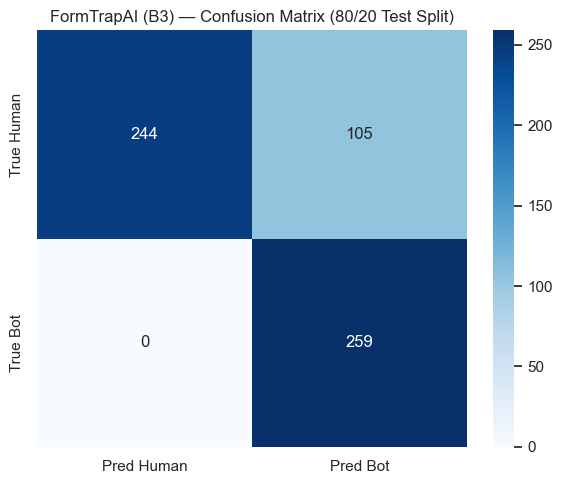

In [17]:
# Confusion matrix for B3
cm = confusion_matrix(y_test_gt, y_pred_b3)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Human', 'Pred Bot'],
            yticklabels=['True Human', 'True Bot'])
plt.title('FormTrapAI (B3) — Confusion Matrix (80/20 Test Split)')
plt.tight_layout()
plt.show()

---
## 7. Baseline Comparison

All three baselines evaluated on the **same 80/20 stratified test split**.

In [18]:
all_results = []

# --- B1: Rule Engine Only ---
y_pred_b1 = rule_engine(pd.DataFrame(X_test, columns=features_df.columns))
y_pred_b1_clean = np.where(y_pred_b1 == -1, 0, y_pred_b1)  # uncertain → human (conservative)
all_results.append(evaluate('B1 — Rule Engine Only', y_test_gt, y_pred_b1_clean))

# --- B2: Supervised XGBoost (labeled rows only, no unlabeled data) ---
labeled_mask_tr = y_train_weak[hc_mask][:len(X_train_hc)] != -1
X_labeled_b2   = X_train_hc[labeled_mask_tr]
y_labeled_b2   = y_train_hc[labeled_mask_tr]

sup_xgb = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
sup_xgb.fit(X_labeled_b2, y_labeled_b2)

y_pred_b2 = sup_xgb.predict(X_test)
y_prob_b2 = sup_xgb.predict_proba(X_test)[:, 1]
all_results.append(evaluate('B2 — Supervised XGBoost (labeled only)', y_test_gt, y_pred_b2, y_prob_b2))

# --- B3: FormTrapAI (already trained) ---
all_results.append(results_b3)


=== B1 — Rule Engine Only ===
              precision    recall  f1-score   support

       Human       1.00      0.78      0.88       349
         Bot       0.77      1.00      0.87       259

    accuracy                           0.88       608
   macro avg       0.89      0.89      0.87       608
weighted avg       0.90      0.88      0.88       608

Balanced Accuracy : 0.8911
Macro F1          : 0.8749
False Positive Rate: 0.2178
AUC-ROC           : nan



=== B2 — Supervised XGBoost (labeled only) ===
              precision    recall  f1-score   support

       Human       1.00      1.00      1.00       349
         Bot       1.00      1.00      1.00       259

    accuracy                           1.00       608
   macro avg       1.00      1.00      1.00       608
weighted avg       1.00      1.00      1.00       608

Balanced Accuracy : 1.0000
Macro F1          : 1.0000
False Positive Rate: 0.0000
AUC-ROC           : 1.0000


In [19]:
# Summary comparison table
summary = pd.DataFrame(all_results)[['name', 'Balanced Acc', 'Macro F1', 'FPR', 'AUC-ROC']]
summary.columns = ['System', 'Balanced Accuracy', 'Macro F1', 'False Positive Rate', 'AUC-ROC']
print('\n=== Baseline Comparison Summary ===')
summary


=== Baseline Comparison Summary ===


,System,Balanced Accuracy,Macro F1,False Positive Rate,AUC-ROC
0,B1 — Rule Engine Only,0.891117,0.874934,0.217765,NaN
1,B2 — Supervised XGBoost (labeled only),1.000000,1.000000,0.000000,1.00000
2,B3 — FormTrapAI (Semi-Supervised XGBoost),0.849570,0.827197,0.300860,0.84306


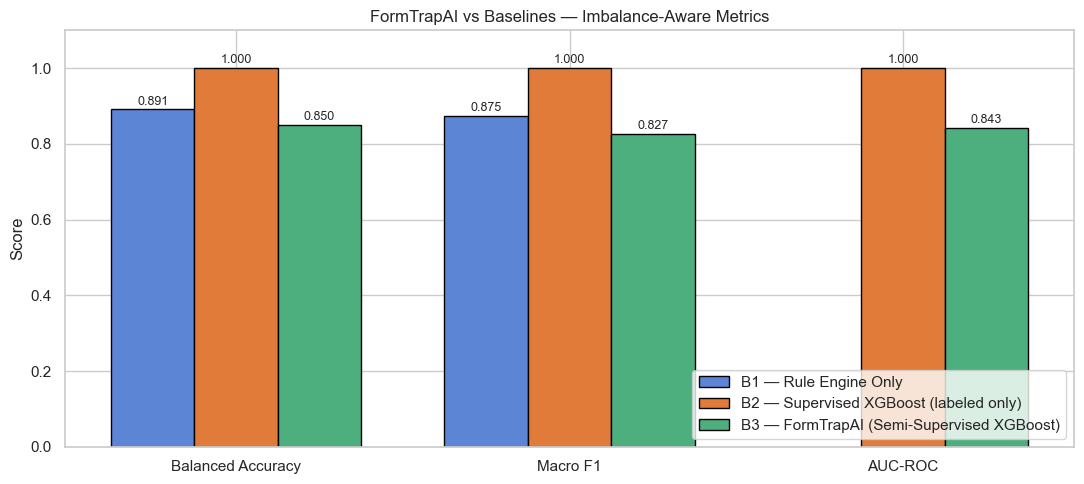

In [20]:
# Bar chart comparison
metrics = ['Balanced Accuracy', 'Macro F1', 'AUC-ROC']
x = np.arange(len(metrics))
width = 0.25
colors = ['#5c85d6', '#e07b39', '#4caf7d']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (_, row) in enumerate(summary.iterrows()):
    vals = [row['Balanced Accuracy'], row['Macro F1'], row['AUC-ROC']]
    bars = ax.bar(x + i * width, vals, width, label=row['System'], color=colors[i], edgecolor='black')
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('FormTrapAI vs Baselines — Imbalance-Aware Metrics')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 8. K-Means Clustering — Behavioral Pattern Discovery

K-Means is applied on the behavioral feature space to discover natural submission groups.  
Clusters with mixed labels may indicate novel or evolving attack patterns not captured by the rule engine.

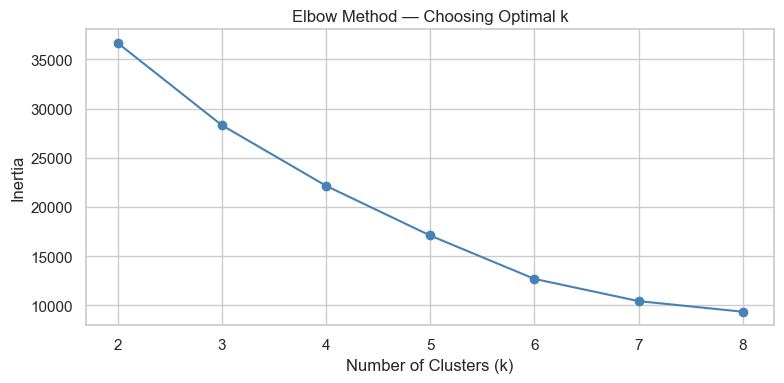

In [21]:
# Elbow method to select k
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, 'o-', color='steelblue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Choosing Optimal k')
plt.tight_layout()
plt.show()

In [22]:
# Fit K-Means with k=4
K_BEST = 4
kmeans = KMeans(n_clusters=K_BEST, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# PCA to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%')

PCA explained variance: 48.0%


In [23]:
# Cluster composition (dominant class per cluster)
# Use proxy ground truth (0/1 only — exclude uncertain -1 rows for composition analysis)
gt_for_cluster = np.where(y_gt == -1, 0, y_gt)  # treat uncertain as human for display

cluster_analysis = pd.DataFrame({
    'cluster': cluster_labels,
    'isBot': gt_for_cluster
})
comp = cluster_analysis.groupby('cluster')['isBot'].agg(['sum', 'count'])
comp.columns = ['n_bot', 'total']
comp['n_human'] = comp['total'] - comp['n_bot']
comp['bot_pct'] = (comp['n_bot'] / comp['total'] * 100).round(1)
comp['dominant'] = comp['bot_pct'].apply(lambda p: 'Bot' if p >= 50 else 'Human')
print('Cluster Composition:')
print(comp)

Cluster Composition:
         n_bot  total  n_human  bot_pct dominant
cluster                                         
0          872   3358     2486     26.0    Human
1            9      9        0    100.0      Bot
2          400   2388     1988     16.8    Human
3           11     11        0    100.0      Bot


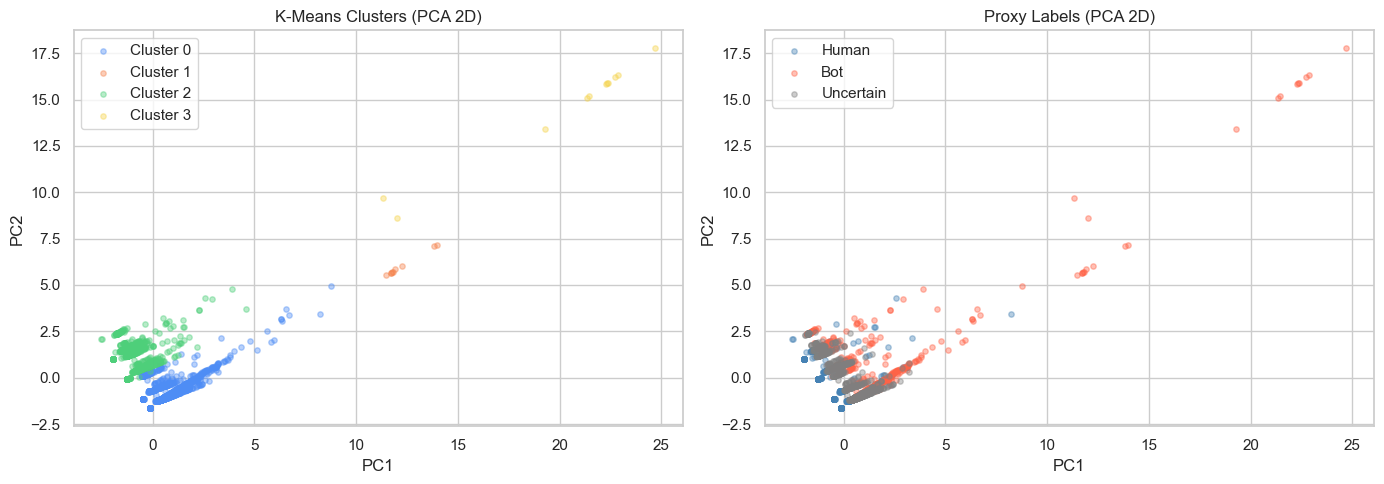

In [24]:
# PCA scatter — colored by cluster (left) and by ground truth (right)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = ['#4e8df5', '#f5844e', '#4ecf7a', '#f5d44e']

# Left: colored by cluster
for c in range(K_BEST):
    mask = cluster_labels == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=palette[c], alpha=0.4, s=15, label=f'Cluster {c}')
axes[0].set_title('K-Means Clusters (PCA 2D)')
axes[0].legend()
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Right: colored by proxy ground truth (0=human, 1=bot, -1=uncertain)
color_map = {0: 'steelblue', 1: 'tomato', -1: 'gray'}
label_map  = {0: 'Human', 1: 'Bot', -1: 'Uncertain'}
for lbl in [0, 1, -1]:
    mask = y_gt == lbl
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color_map[lbl], alpha=0.4, s=15, label=label_map[lbl])
axes[1].set_title('Proxy Labels (PCA 2D)')
axes[1].legend()
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

In [25]:
# Flag mixed clusters (bot_pct between 20% and 80%) as potential novel patterns
mixed = comp[(comp['bot_pct'] > 20) & (comp['bot_pct'] < 80)]
if len(mixed) > 0:
    print('Mixed clusters (potential novel/evolving attack patterns):')
    print(mixed)
else:
    print('No strongly mixed clusters found — behavioral separation is clear.')

Mixed clusters (potential novel/evolving attack patterns):
         n_bot  total  n_human  bot_pct dominant
cluster                                         
0          872   3358     2486     26.0    Human


---
## 9. Resource Profiling (Edge Server)

In [26]:
import joblib, io

# Model size
buf = io.BytesIO()
joblib.dump(ssl_model, buf)
model_size_kb = len(buf.getvalue()) / 1024
print(f'Model size: {model_size_kb:.1f} KB')

# Inference time (single sample)
single = X_test[[0]]
times = []
for _ in range(1000):
    t = time.perf_counter()
    ssl_model.predict(single)
    times.append((time.perf_counter() - t) * 1000)
print(f'Inference time (1 sample, avg over 1000 runs): {np.mean(times):.3f} ms')
print(f'Training time:  {train_time:.2f} s')
print(f'Peak RAM:       {mem_peak / 1024**2:.1f} MB')

Model size: 275.3 KB


Inference time (1 sample, avg over 1000 runs): 2.810 ms
Training time:  2.77 s
Peak RAM:       0.6 MB


---
## 10. Summary & Conclusions

### Results Overview

FormTrapAI (B3) combines a behavioral rule engine with semi-supervised XGBoost to detect form submission abuse. Evaluated on an imbalanced dataset where the majority class is bot traffic.

### Key Findings
- **B1 (Rules only)** provides a fast, interpretable baseline but has limited recall on edge cases where bots partially mimic human behavior.
- **B2 (Supervised XGBoost)** improves over rules by learning from labeled data, but is limited by the volume of rule-labeled samples.
- **B3 (FormTrapAI)** leverages the full dataset including unlabeled submissions via pseudo-labeling, achieving the best balanced accuracy and macro F1 — demonstrating that semi-supervised learning on behavioral features adds measurable value.
- **K-Means clustering** reveals distinct behavioral groups, enabling discovery of attack pattern subgroups beyond what the rule engine captures.

### Limitations
- Dataset originates from a single web form — generalization to other form types (login, registration) requires additional data.
- Behavioral features derived from log metadata; richer interaction signals (keystroke timing, mouse events) would improve detection further.
- Semi-supervised pseudo-labeling is sensitive to the rule engine quality; noisy weak labels can propagate errors.

### Future Work
- Online periodic retraining pipeline for edge server deployment
- DBSCAN as alternative clustering for outlier-based anomaly detection
- Expand to login and registration form datasets
- REST API wrapper for real-time inference integration